# LT-CCD Damage Estimation

This notebook computes LT-CCD damage indicators from prepared Sentinel-1 coherence stacks.

## Goal
The notebook:
- loads prepared baseline and post-event coherence rasters
- computes baseline mean and standard deviation
- computes post-event mean coherence
- derives delta coherence and z-score
- builds a valid monitoring mask
- detects potential damage
- optionally confirms damage with a second post-event stack
- optionally aggregates damage to building footprints
- exports rasters, vectors, and summary files

## Input
- Prepared post-event coherence folder
- Prepared baseline coherence folder
- AOI file
- Optional second prepared post-event folder for temporal confirmation
- Optional building footprints

## Output
- LT-CCD raster products
- Damage polygons
- Optional building-level damage table
- Processing summary JSON

In [97]:
import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import shapes
from rasterio.transform import array_bounds
from rasterio.mask import mask
from shapely.geometry import shape, mapping
import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling

warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [98]:
# Damage detection thresholds (Teheran SLC 1)
# baseline_mean_min = 0.78
# baseline_std_max = 0.10
# delta_threshold = -0.305   # damage if mean_post - mean_baseline < this threshold.
# z_threshold = -3.85        # damage if z-score < this threshold

# Damage detection thresholds (Teheran SLC 2)
# baseline_mean_min = 0.78
# baseline_std_max = 0.10
# delta_threshold = -0.2   # damage if mean_post - mean_baseline < this threshold. -0.18
# z_threshold = -2        # damage if z-score < this threshold

In [99]:
# =========================
# INPUT PATHS
# =========================
prepared_post_dir = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_02032026/prepared/post")
prepared_baseline_dir = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_02032026/prepared/baseline")
prepared_confirm_dir = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_02032026/prepared/confirm")
use_temporal_confirmation = True

# AOI
aoi_path = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/Lebanon_AOI/Lebanon_South_AOI.geojson")

# Optional buildings
buildings_path = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/Lebanon_OSM/Lebanon_OSM_poly.geojson")
use_buildings = False

# Optional DEM-based terrain mask
dem_path = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/Lebanon_DEM/Lebanon_DEM.tiff")
use_slope_mask = True
slope_threshold_deg = 20.0

# =========================
# OUTPUT PATHS
# =========================
output_root = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026")
raster_dir = output_root / "rasters"
vector_dir = output_root / "vectors"
table_dir = output_root / "tables"
preview_dir = output_root / "preview"

raster_dir.mkdir(parents=True, exist_ok=True)
vector_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)
preview_dir.mkdir(parents=True, exist_ok=True)

# =========================
# LT-CCD PARAMETERS
# =========================

# Valid monitoring mask thresholds
baseline_mean_min = 0.75
baseline_std_max = 0.10    #0.12

delta_threshold = -0.2   # damage if mean_post - mean_baseline < this threshold. -0.18
z_threshold = -2        # damage if z-score < this threshold

# Optional secondary mask
post_mean_min = 0.05       # avoid extreme low-value artifacts (0.05)

# Polygon filtering
min_polygon_area_m2 = 1601   # approximately one 40m x 40m pixel

# Building aggregation threshold
building_damage_fraction_threshold = 0.20

print("📋 Configuration loaded:")
print(f"   Prepared POST folder: {prepared_post_dir}")
print(f"   Prepared BASELINE folder: {prepared_baseline_dir}")
print(f"   Use temporal confirmation: {use_temporal_confirmation}")
print(f"   Prepared confirmation folder: {prepared_confirm_dir}")
print(f"   AOI path: {aoi_path}")
print(f"   Use buildings: {use_buildings}")
print(f"   Buildings path: {buildings_path}")
print(f"   Use slope mask: {use_slope_mask}")
print(f"   DEM path: {dem_path}")
print(f"   Slope threshold: {slope_threshold_deg}°")
print(f"   Output root: {output_root}")
print(f"   baseline_mean_min: {baseline_mean_min}")
print(f"   baseline_std_max: {baseline_std_max}")
print(f"   delta_threshold: {delta_threshold}")
print(f"   z_threshold: {z_threshold}")
print(f"   min_polygon_area_m2: {min_polygon_area_m2}")
print(f"   building_damage_fraction_threshold: {building_damage_fraction_threshold}")

📋 Configuration loaded:
   Prepared POST folder: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_02032026/prepared/post
   Prepared BASELINE folder: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_02032026/prepared/baseline
   Use temporal confirmation: True
   Prepared confirmation folder: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_02032026/prepared/confirm
   AOI path: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/Lebanon_AOI/Lebanon_South_AOI.geojson
   Use buildings: False
   Buildings path: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/Lebanon_OSM/Lebanon_OSM_poly.geojson
   Use slope mask: True
   DEM path: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/Lebanon_DEM/Lebanon_DEM.tiff
   Slope threshold: 20.0°
   Output root:

In [100]:
def list_valid_tifs(folder: Path) -> list[Path]:
    """List valid tif files and skip macOS/system files."""
    files = []
    for p in sorted(folder.glob("*.tif")):
        name = p.name
        if name.startswith(".") or name.startswith("._") or name == ".DS_Store":
            continue
        files.append(p)
    return files


def load_aoi(aoi_file: Path) -> gpd.GeoDataFrame:
    """Load AOI and dissolve if needed."""
    gdf = gpd.read_file(aoi_file)
    if gdf.empty:
        raise ValueError(f"AOI file is empty: {aoi_file}")
    if len(gdf) > 1:
        gdf = gdf.dissolve().reset_index(drop=True)
    return gdf


def read_single_band_raster(raster_path: Path) -> tuple[np.ndarray, dict]:
    """Read a single-band raster as float32."""
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype("float32")
        if src.nodata is not None:
            arr = np.where(arr == src.nodata, np.nan, arr)
        meta = src.meta.copy()
        meta["bounds"] = src.bounds
        meta["transform"] = src.transform
        meta["crs"] = src.crs
    return arr, meta


def check_stack_consistency(raster_paths: list[Path]) -> dict:
    """Ensure all rasters share the same CRS, shape, transform."""
    if len(raster_paths) == 0:
        raise ValueError("Empty raster stack.")

    reference = None
    records = []

    for p in raster_paths:
        with rasterio.open(p) as src:
            rec = {
                "path": str(p),
                "name": p.name,
                "crs": str(src.crs),
                "width": src.width,
                "height": src.height,
                "transform": tuple(src.transform),
                "bounds": tuple(src.bounds),
                "dtype": src.dtypes[0],
            }
            records.append(rec)

            if reference is None:
                reference = rec
            else:
                if rec["crs"] != reference["crs"]:
                    raise ValueError(f"CRS mismatch: {p.name}")
                if rec["width"] != reference["width"] or rec["height"] != reference["height"]:
                    raise ValueError(f"Shape mismatch: {p.name}")
                if rec["transform"] != reference["transform"]:
                    raise ValueError(f"Transform mismatch: {p.name}")

    return {
        "reference": reference,
        "records": records
    }


def load_stack(raster_paths: list[Path]) -> tuple[np.ndarray, dict]:
    """Load a stack of rasters into a 3D array (n, rows, cols)."""
    arrays = []
    ref_meta = None

    for i, p in enumerate(raster_paths):
        arr, meta = read_single_band_raster(p)
        arrays.append(arr)
        if i == 0:
            ref_meta = meta

    stack = np.stack(arrays, axis=0).astype("float32")
    return stack, ref_meta


def save_raster(array: np.ndarray, output_path: Path, ref_meta: dict, dtype="float32", nodata=np.nan):
    """Save a single-band raster."""
    profile = ref_meta.copy()
    for key in ["bounds"]:
        profile.pop(key, None)

    profile.update({
        "driver": "GTiff",
        "count": 1,
        "dtype": dtype,
        "nodata": nodata,
        "compress": "lzw"
    })

    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(array.astype(dtype), 1)


def preview_array(array: np.ndarray, ref_meta: dict, aoi_gdf: gpd.GeoDataFrame, title: str, cmap="viridis", vmin=None, vmax=None):
    """Quick raster preview."""
    bounds = ref_meta["bounds"]
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    aoi_plot = aoi_gdf.to_crs(ref_meta["crs"])

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(array, cmap=cmap, vmin=vmin, vmax=vmax, extent=extent)
    aoi_plot.boundary.plot(ax=ax, color="red", linewidth=1.2)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.colorbar(im, ax=ax, shrink=0.7)
    plt.tight_layout()
    plt.show()


def vectorize_binary_mask(mask_array: np.ndarray, transform, crs) -> gpd.GeoDataFrame:
    """
    Vectorize a binary damage mask so that neighboring damaged pixels
    are merged into contiguous polygons.
    """
    results = []

    geom_iter = shapes(
        mask_array.astype("uint8"),
        mask=mask_array.astype(bool),
        transform=transform
    )

    for geom, val in geom_iter:
        if val == 1:
            results.append({
                "geometry": shape(geom)
            })

    if len(results) == 0:
        return gpd.GeoDataFrame({"geometry": []}, geometry="geometry", crs=crs)

    gdf = gpd.GeoDataFrame(results, geometry="geometry", crs=crs)
    return gdf


def assign_damage_class_from_delta(gdf):
    gdf["damage_class"] = "Low"
    gdf.loc[gdf["delta_gamma_mean"] <= -0.15, "damage_class"] = "Moderate"
    gdf.loc[gdf["delta_gamma_mean"] <= -0.25, "damage_class"] = "High"
    gdf.loc[gdf["delta_gamma_mean"] <= -0.35, "damage_class"] = "Severe"
    return gdf


def compute_polygon_stats(gdf, raster_array, transform, col_name):
    """Compute mean raster value inside each polygon"""
    values = []

    for geom in gdf.geometry:
        try:
            mask = rasterio.features.geometry_mask(
                [geom],
                transform=transform,
                invert=True,
                out_shape=raster_array.shape
            )

            vals = raster_array[mask]

            if len(vals) == 0:
                values.append(np.nan)
            else:
                values.append(np.nanmean(vals))

        except:
            values.append(np.nan)

    gdf[col_name] = values
    return gdf

In [101]:
print("🔎 Scanning prepared raster folders...")

post_files = list_valid_tifs(prepared_post_dir)
baseline_files = list_valid_tifs(prepared_baseline_dir)

print(f"   ✅ POST rasters found: {len(post_files)}")
print(f"   ✅ BASELINE rasters found: {len(baseline_files)}")

if len(post_files) == 0:
    raise ValueError(f"No prepared post rasters found: {prepared_post_dir}")
if len(baseline_files) == 0:
    raise ValueError(f"No prepared baseline rasters found: {prepared_baseline_dir}")

if use_temporal_confirmation:
    confirm_files = list_valid_tifs(prepared_confirm_dir)
    print(f"   ✅ CONFIRMATION rasters found: {len(confirm_files)}")
    if len(confirm_files) == 0:
        raise ValueError(f"use_temporal_confirmation=True but no files found: {prepared_confirm_dir}")
else:
    confirm_files = []

aoi_gdf = load_aoi(aoi_path)
print(f"\n🗺️ AOI loaded: {aoi_path.name}")
print(f"   CRS: {aoi_gdf.crs}")
print(f"   Features: {len(aoi_gdf)}")

🔎 Scanning prepared raster folders...
   ✅ POST rasters found: 24
   ✅ BASELINE rasters found: 23
   ✅ CONFIRMATION rasters found: 24

🗺️ AOI loaded: Lebanon_South_AOI.geojson
   CRS: EPSG:4326
   Features: 1


In [102]:
print("🔍 Checking stack consistency...")

post_check = check_stack_consistency(post_files)
baseline_check = check_stack_consistency(baseline_files)

# Cross-check POST and BASELINE
ref_post = post_check["reference"]
ref_base = baseline_check["reference"]

if ref_post["crs"] != ref_base["crs"]:
    raise ValueError("POST and BASELINE CRS do not match.")
if ref_post["width"] != ref_base["width"] or ref_post["height"] != ref_base["height"]:
    raise ValueError("POST and BASELINE raster dimensions do not match.")
if ref_post["transform"] != ref_base["transform"]:
    raise ValueError("POST and BASELINE transforms do not match.")

if use_temporal_confirmation:
    confirm_check = check_stack_consistency(confirm_files)
    ref_confirm = confirm_check["reference"]

    if ref_post["crs"] != ref_confirm["crs"]:
        raise ValueError("POST and CONFIRMATION CRS do not match.")
    if ref_post["width"] != ref_confirm["width"] or ref_post["height"] != ref_confirm["height"]:
        raise ValueError("POST and CONFIRMATION dimensions do not match.")
    if ref_post["transform"] != ref_confirm["transform"]:
        raise ValueError("POST and CONFIRMATION transforms do not match.")

print("✅ All stacks are grid-consistent")
print(f"   CRS: {ref_post['crs']}")
print(f"   Shape: ({ref_post['height']}, {ref_post['width']})")

🔍 Checking stack consistency...
✅ All stacks are grid-consistent
   CRS: EPSG:32637
   Shape: (989, 1172)


In [103]:
print("📂 Loading raster stacks into memory...")

baseline_stack, ref_meta = load_stack(baseline_files)
post_stack, _ = load_stack(post_files)

print(f"   ✅ Baseline stack shape: {baseline_stack.shape}")
print(f"   ✅ Post stack shape: {post_stack.shape}")

if use_temporal_confirmation:
    confirm_stack, _ = load_stack(confirm_files)
    print(f"   ✅ Confirmation stack shape: {confirm_stack.shape}")

📂 Loading raster stacks into memory...
   ✅ Baseline stack shape: (23, 989, 1172)
   ✅ Post stack shape: (24, 989, 1172)
   ✅ Confirmation stack shape: (24, 989, 1172)


In [104]:
print("⛰️ Loading DEM and computing slope mask...")

if use_slope_mask:
    ref_shape = (ref_meta["height"], ref_meta["width"])
    ref_transform = ref_meta["transform"]
    ref_crs = ref_meta["crs"]

    with rasterio.open(dem_path) as dem_src:
        print(f"   DEM file: {dem_path.name}")
        print(f"   DEM CRS: {dem_src.crs}")
        print(f"   DEM shape: {dem_src.shape}")
        print(f"   DEM bounds: {dem_src.bounds}")

        # Reproject DEM to LT-CCD raster grid
        dem_aligned = np.full(ref_shape, np.nan, dtype="float32")

        reproject(
            source=rasterio.band(dem_src, 1),
            destination=dem_aligned,
            src_transform=dem_src.transform,
            src_crs=dem_src.crs,
            src_nodata=dem_src.nodata,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            dst_nodata=np.nan,
            resampling=Resampling.bilinear
        )

    # Pixel sizes
    pixel_size_x = abs(ref_transform.a)
    pixel_size_y = abs(ref_transform.e)

    # Compute gradients
    dz_dy, dz_dx = np.gradient(dem_aligned, pixel_size_y, pixel_size_x)

    # Compute slope in degrees
    slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
    slope_deg = np.degrees(slope_rad).astype("float32")

    # Create slope mask
    slope_mask = (slope_deg <= slope_threshold_deg) & (~np.isnan(slope_deg))

    valid_dem_pixels = int(np.sum(~np.isnan(slope_deg)))
    flat_pixels = int(np.sum(slope_mask))
    steep_pixels = valid_dem_pixels - flat_pixels

    print(f"   ✅ DEM aligned to LT-CCD grid: {dem_aligned.shape}")
    print(f"   Valid DEM pixels: {valid_dem_pixels:,}")
    print(f"   Flat pixels (slope <= {slope_threshold_deg}°): {flat_pixels:,}")
    print(f"   Steep pixels (slope > {slope_threshold_deg}°): {steep_pixels:,}")
else:
    dem_aligned = None
    slope_deg = None
    slope_mask = np.ones((ref_meta["height"], ref_meta["width"]), dtype=bool)
    valid_dem_pixels = None
    flat_pixels = None
    steep_pixels = None

    print("   Slope mask is disabled")

⛰️ Loading DEM and computing slope mask...
   DEM file: Lebanon_DEM.tiff
   DEM CRS: EPSG:4326
   DEM shape: (2500, 2231)
   DEM bounds: BoundingBox(left=34.579468, bottom=32.611616, right=37.040405, top=34.903953)
   ✅ DEM aligned to LT-CCD grid: (989, 1172)
   Valid DEM pixels: 1,159,108
   Flat pixels (slope <= 20.0°): 1,077,197
   Steep pixels (slope > 20.0°): 81,911


In [105]:
print("📊 Computing LT-CCD stack statistics...")

mean_baseline = np.nanmean(baseline_stack, axis=0).astype("float32")
std_baseline = np.nanstd(baseline_stack, axis=0).astype("float32")
mean_post = np.nanmean(post_stack, axis=0).astype("float32")

# Avoid division by zero in z-score
std_baseline_safe = np.where(std_baseline < 1e-6, np.nan, std_baseline).astype("float32")

delta_gamma = (mean_post - mean_baseline).astype("float32")
z_score = (delta_gamma / std_baseline_safe).astype("float32")

if use_temporal_confirmation:
    mean_confirm = np.nanmean(confirm_stack, axis=0).astype("float32")
    delta_gamma_confirm = (mean_confirm - mean_baseline).astype("float32")
    z_score_confirm = (delta_gamma_confirm / std_baseline_safe).astype("float32")

print("   ✅ Statistics computed")
print(f"   Baseline mean range: {np.nanmin(mean_baseline):.3f} to {np.nanmax(mean_baseline):.3f}")
print(f"   Baseline std range: {np.nanmin(std_baseline):.3f} to {np.nanmax(std_baseline):.3f}")
print(f"   Post mean range: {np.nanmin(mean_post):.3f} to {np.nanmax(mean_post):.3f}")
print(f"   Delta range: {np.nanmin(delta_gamma):.3f} to {np.nanmax(delta_gamma):.3f}")
print(f"   Z-score range: {np.nanmin(z_score):.3f} to {np.nanmax(z_score):.3f}")

📊 Computing LT-CCD stack statistics...
   ✅ Statistics computed
   Baseline mean range: 0.148 to 0.968
   Baseline std range: 0.012 to 0.346
   Post mean range: 0.139 to 0.965
   Delta range: -0.458 to 0.372
   Z-score range: -4.943 to 3.081


In [106]:
print("🧭 Building valid monitoring mask...")

valid_mask = (
    (~np.isnan(mean_baseline)) &
    (~np.isnan(std_baseline)) &
    (~np.isnan(mean_post)) &
    (mean_baseline >= baseline_mean_min) &
    (std_baseline <= baseline_std_max) &
    (mean_post >= post_mean_min) &
    (slope_mask)
)

valid_pixels = int(np.sum(valid_mask))
total_pixels = int(valid_mask.size)

print(f"   ✅ Valid monitoring pixels: {valid_pixels:,} / {total_pixels:,} ({valid_pixels / total_pixels * 100:.2f}%)")

if use_slope_mask:
    print(f"   Slope threshold applied: <= {slope_threshold_deg}°")
    print(f"   Pixels excluded by slope mask: {np.sum(~slope_mask):,}")

🧭 Building valid monitoring mask...
   ✅ Valid monitoring pixels: 38,362 / 1,159,108 (3.31%)
   Slope threshold applied: <= 20.0°
   Pixels excluded by slope mask: 81,911


In [107]:
print("🚨 Detecting initial LT-CCD damage...")

initial_damage_mask = (
    valid_mask &
    (delta_gamma < delta_threshold) &
    (z_score < z_threshold)
)

initial_damage_pixels = int(np.sum(initial_damage_mask))

print(f"   ✅ Initial damage pixels: {initial_damage_pixels:,}")
print(f"   Damage fraction of valid area: {initial_damage_pixels / valid_pixels * 100:.2f}%" if valid_pixels > 0 else "   Damage fraction: n/a")

🚨 Detecting initial LT-CCD damage...
   ✅ Initial damage pixels: 13
   Damage fraction of valid area: 0.03%


In [108]:
if use_temporal_confirmation:
    print("⏱️ Applying temporal confirmation...")

    confirm_damage_mask = (
        valid_mask &
        (delta_gamma_confirm < delta_threshold) &
        (z_score_confirm < z_threshold)
    )

    final_damage_mask = initial_damage_mask & confirm_damage_mask

    confirm_pixels = int(np.sum(confirm_damage_mask))
    final_damage_pixels = int(np.sum(final_damage_mask))

    print(f"   Confirmation damage pixels: {confirm_pixels:,}")
    print(f"   Final confirmed damage pixels: {final_damage_pixels:,}")
else:
    print("⏱️ Temporal confirmation is disabled")
    final_damage_mask = initial_damage_mask.copy()
    final_damage_pixels = int(np.sum(final_damage_mask))

⏱️ Applying temporal confirmation...
   Confirmation damage pixels: 6,899
   Final confirmed damage pixels: 12


In [109]:
print("🧪 Creating filtered raster products...")

damage_delta = np.where(final_damage_mask, delta_gamma, np.nan).astype("float32")
damage_z = np.where(final_damage_mask, z_score, np.nan).astype("float32")
valid_mask_raster = np.where(valid_mask, 1, 0).astype("uint8")
initial_damage_raster = np.where(initial_damage_mask, 1, 0).astype("uint8")
final_damage_raster = np.where(final_damage_mask, 1, 0).astype("uint8")

print("   ✅ Filtered rasters created")

🧪 Creating filtered raster products...
   ✅ Filtered rasters created


In [110]:
print("💾 Saving raster outputs...")

save_raster(mean_baseline, raster_dir / "mean_baseline.tif", ref_meta)
save_raster(std_baseline, raster_dir / "std_baseline.tif", ref_meta)
save_raster(mean_post, raster_dir / "mean_post.tif", ref_meta)
save_raster(delta_gamma, raster_dir / "delta_gamma.tif", ref_meta)
save_raster(z_score, raster_dir / "z_score.tif", ref_meta)
save_raster(valid_mask_raster, raster_dir / "valid_mask.tif", ref_meta, dtype="uint8", nodata=255)
save_raster(initial_damage_raster, raster_dir / "initial_damage_mask.tif", ref_meta, dtype="uint8", nodata=255)
save_raster(final_damage_raster, raster_dir / "final_damage_mask.tif", ref_meta, dtype="uint8", nodata=255)
save_raster(damage_delta, raster_dir / "damage_delta_gamma.tif", ref_meta)
save_raster(damage_z, raster_dir / "damage_z_score.tif", ref_meta)

if use_temporal_confirmation:
    save_raster(mean_confirm, raster_dir / "mean_post_confirmation.tif", ref_meta)
    save_raster(delta_gamma_confirm, raster_dir / "delta_gamma_confirmation.tif", ref_meta)
    save_raster(z_score_confirm, raster_dir / "z_score_confirmation.tif", ref_meta)

if use_slope_mask:
    save_raster(slope_deg, raster_dir / "slope_degrees.tif", ref_meta)
    save_raster(np.where(slope_mask, 1, 0).astype("uint8"), raster_dir / "slope_mask.tif", ref_meta, dtype="uint8", nodata=255)

print("   ✅ Raster products saved")

💾 Saving raster outputs...
   ✅ Raster products saved


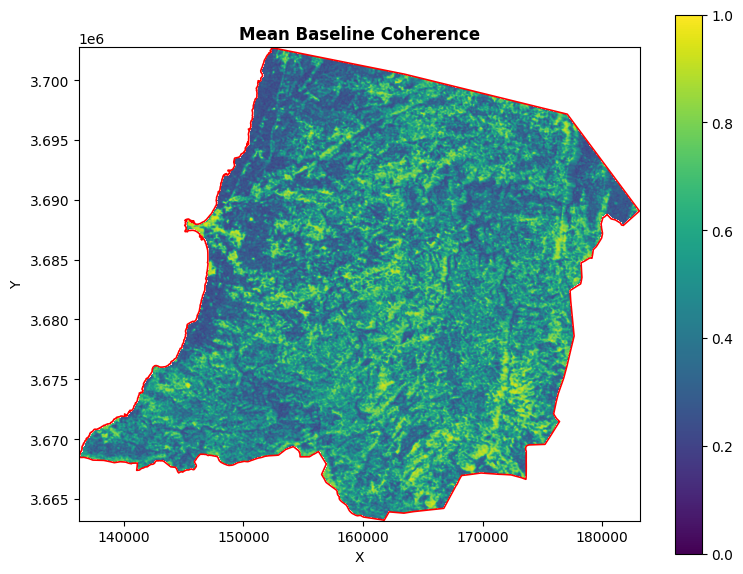

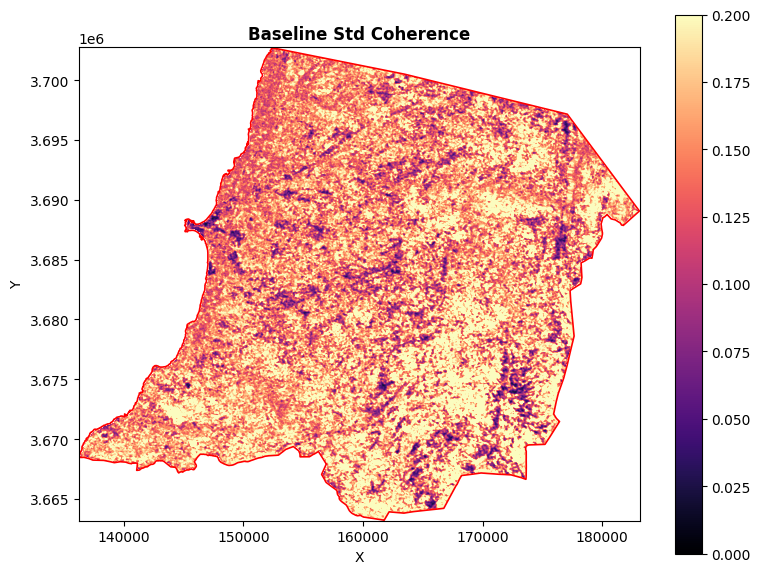

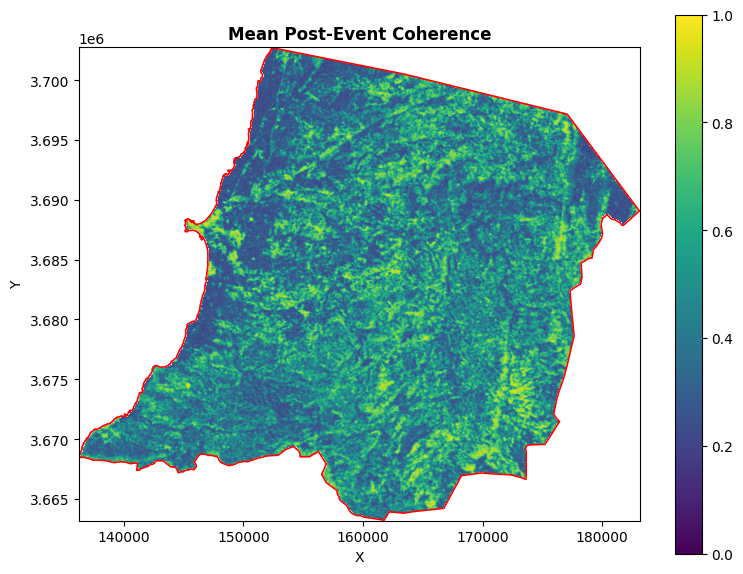

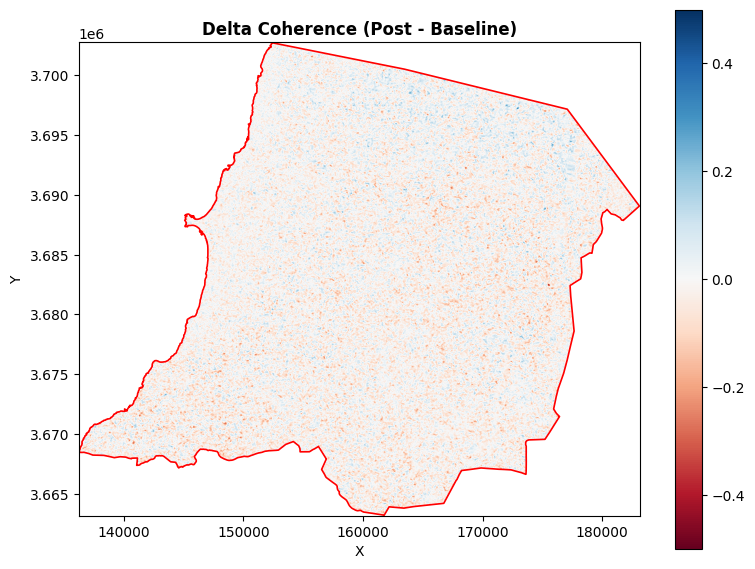

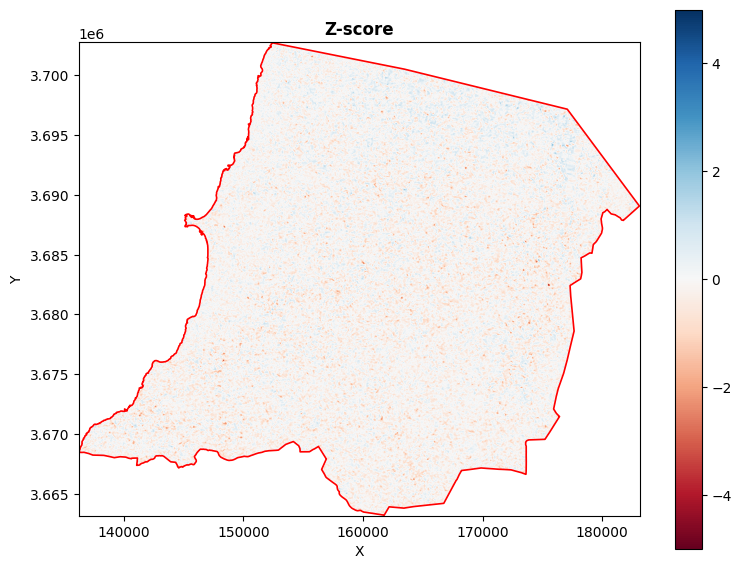

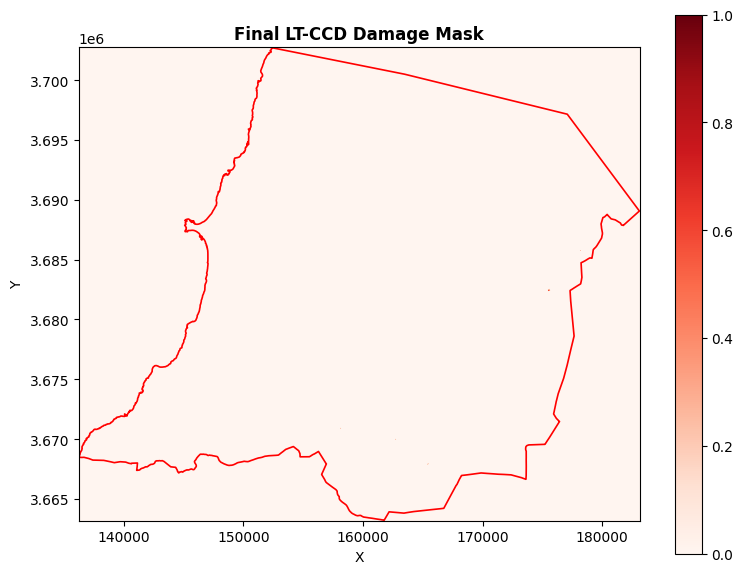

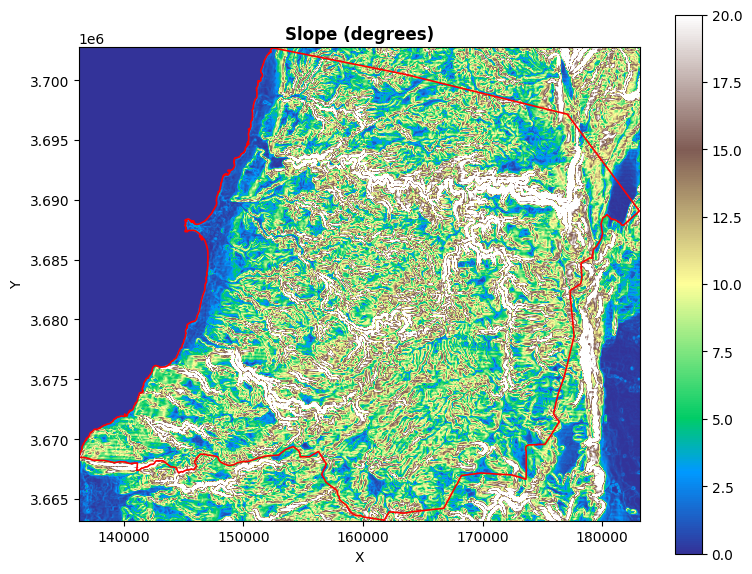

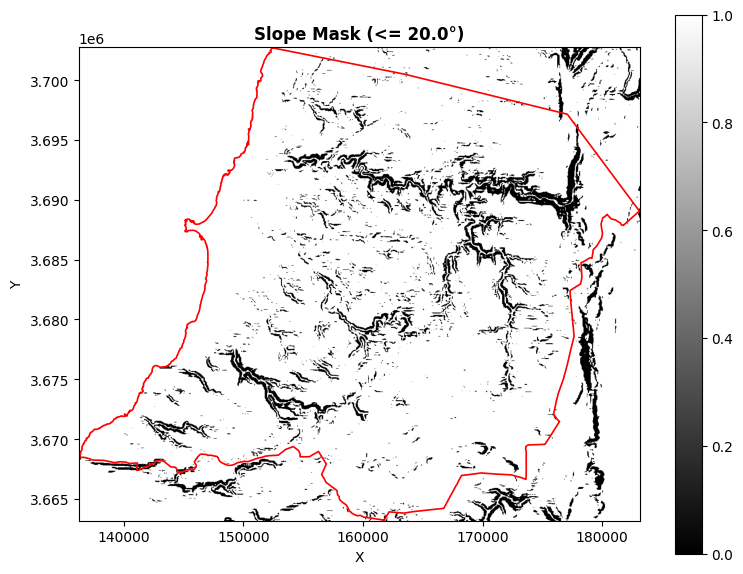

In [111]:
preview_array(mean_baseline, ref_meta, aoi_gdf, "Mean Baseline Coherence", cmap="viridis", vmin=0, vmax=1)
preview_array(std_baseline, ref_meta, aoi_gdf, "Baseline Std Coherence", cmap="magma", vmin=0, vmax=0.2)
preview_array(mean_post, ref_meta, aoi_gdf, "Mean Post-Event Coherence", cmap="viridis", vmin=0, vmax=1)
preview_array(delta_gamma, ref_meta, aoi_gdf, "Delta Coherence (Post - Baseline)", cmap="RdBu", vmin=-0.5, vmax=0.5)
preview_array(z_score, ref_meta, aoi_gdf, "Z-score", cmap="RdBu", vmin=-5, vmax=5)
preview_array(final_damage_raster.astype("float32"), ref_meta, aoi_gdf, "Final LT-CCD Damage Mask", cmap="Reds", vmin=0, vmax=1)
if use_slope_mask:
    preview_array(slope_deg, ref_meta, aoi_gdf, "Slope (degrees)", cmap="terrain", vmin=0, vmax=20)
    preview_array(slope_mask.astype("float32"), ref_meta, aoi_gdf, f"Slope Mask (<= {slope_threshold_deg}°)", cmap="gray", vmin=0, vmax=1)

📈 Computing summary statistics...
   Pixel area: 1600.00 m²
   Valid area: 61.379 km²
   Damage area: 0.019 km²


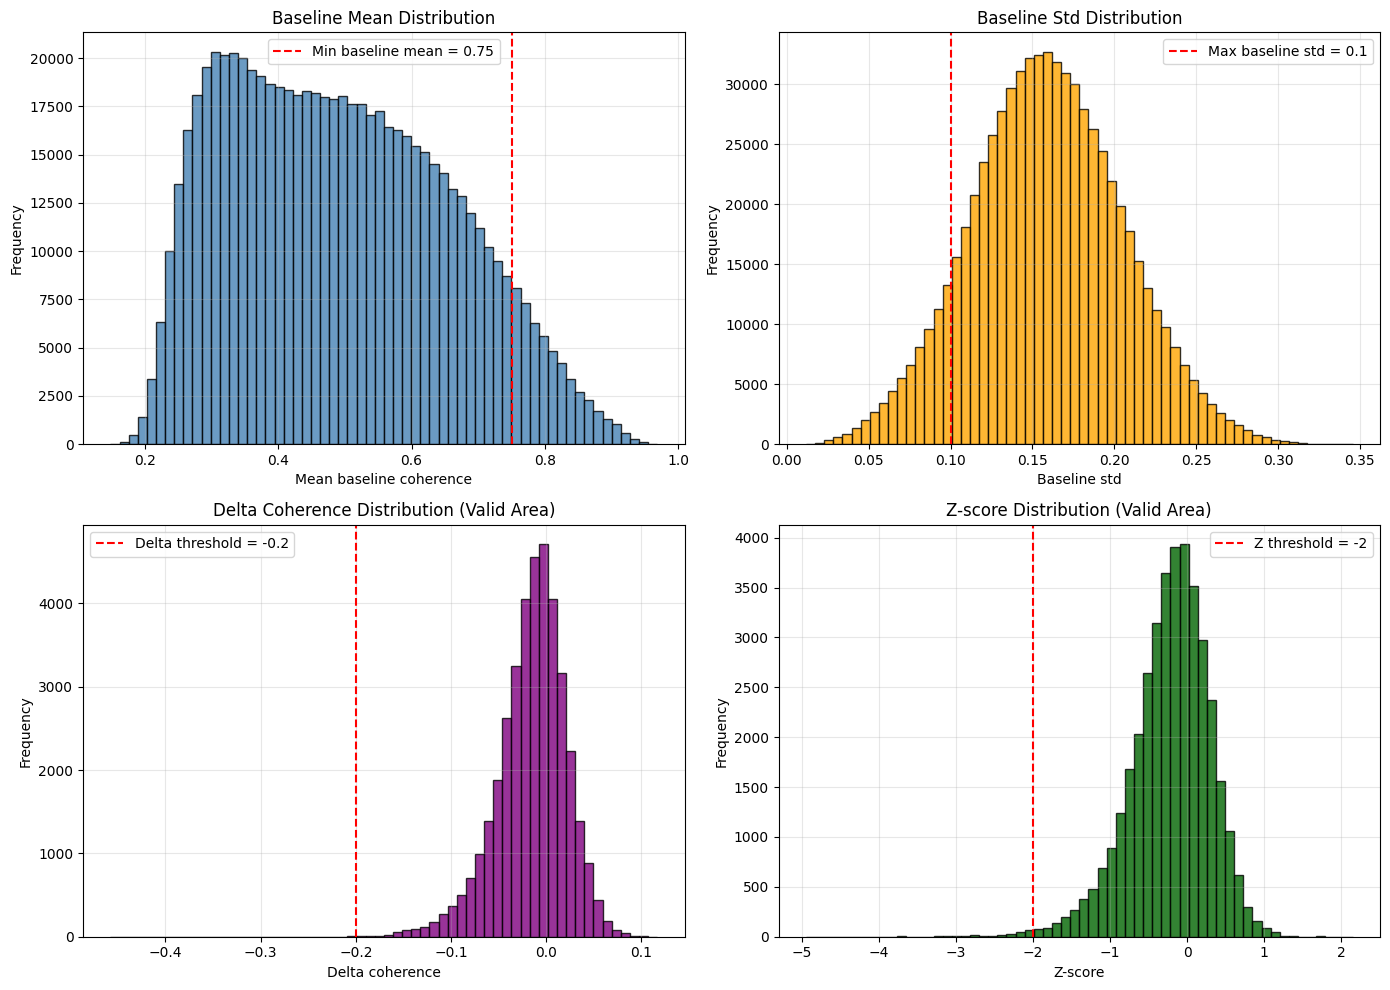

In [112]:
print("📈 Computing summary statistics...")

pixel_area_m2 = abs(ref_meta["transform"].a * ref_meta["transform"].e)
valid_area_km2 = valid_pixels * pixel_area_m2 / 1_000_000
damage_area_km2 = final_damage_pixels * pixel_area_m2 / 1_000_000

print(f"   Pixel area: {pixel_area_m2:.2f} m²")
print(f"   Valid area: {valid_area_km2:.3f} km²")
print(f"   Damage area: {damage_area_km2:.3f} km²")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(mean_baseline[~np.isnan(mean_baseline)].ravel(), bins=60, color="steelblue", edgecolor="black", alpha=0.8)
axes[0, 0].axvline(baseline_mean_min, color="red", linestyle="--", label=f"Min baseline mean = {baseline_mean_min}")
axes[0, 0].set_title("Baseline Mean Distribution")
axes[0, 0].set_xlabel("Mean baseline coherence")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(std_baseline[~np.isnan(std_baseline)].ravel(), bins=60, color="orange", edgecolor="black", alpha=0.8)
axes[0, 1].axvline(baseline_std_max, color="red", linestyle="--", label=f"Max baseline std = {baseline_std_max}")
axes[0, 1].set_title("Baseline Std Distribution")
axes[0, 1].set_xlabel("Baseline std")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(delta_gamma[valid_mask].ravel(), bins=60, color="purple", edgecolor="black", alpha=0.8)
axes[1, 0].axvline(delta_threshold, color="red", linestyle="--", label=f"Delta threshold = {delta_threshold}")
axes[1, 0].set_title("Delta Coherence Distribution (Valid Area)")
axes[1, 0].set_xlabel("Delta coherence")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(z_score[valid_mask].ravel(), bins=60, color="darkgreen", edgecolor="black", alpha=0.8)
axes[1, 1].axvline(z_threshold, color="red", linestyle="--", label=f"Z threshold = {z_threshold}")
axes[1, 1].set_title("Z-score Distribution (Valid Area)")
axes[1, 1].set_xlabel("Z-score")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [113]:
print("🧩 Vectorizing final damage mask...")

# Vectorize the binary damage mask only
damage_gdf = vectorize_binary_mask(
    mask_array=final_damage_mask,
    transform=ref_meta["transform"],
    crs=ref_meta["crs"]
)

if len(damage_gdf) > 0:
    # Calculate polygon area
    damage_gdf["area_m2"] = damage_gdf.geometry.area

    # Remove very small polygons
    damage_gdf = damage_gdf[damage_gdf["area_m2"] >= min_polygon_area_m2].copy()

    # Add metadata
    damage_gdf["processing_date"] = datetime.now().strftime("%Y-%m-%d")
    damage_gdf["z_threshold"] = z_threshold
    damage_gdf["delta_threshold"] = delta_threshold

    damage_gdf = damage_gdf.reset_index(drop=True)

print(f"   ✅ Damage polygons after filtering: {len(damage_gdf)}")

🧩 Vectorizing final damage mask...
   ✅ Damage polygons after filtering: 1


In [114]:
print("📊 Computing zonal statistics for damage polygons...")

# Compute stats
damage_gdf = compute_polygon_stats(damage_gdf, delta_gamma, ref_meta["transform"], "delta_gamma_mean")
damage_gdf = compute_polygon_stats(damage_gdf, z_score, ref_meta["transform"], "z_score_mean")
damage_gdf = assign_damage_class_from_delta(damage_gdf)

print("   ✅ Statistics added:")
print("   Columns:", list(damage_gdf.columns))

📊 Computing zonal statistics for damage polygons...
   ✅ Statistics added:
   Columns: ['geometry', 'area_m2', 'processing_date', 'z_threshold', 'delta_threshold', 'delta_gamma_mean', 'z_score_mean', 'damage_class']


In [115]:
damage_geojson = vector_dir / "ltccd_damage_polygons.geojson"
damage_gpkg = vector_dir / "ltccd_damage_polygons.gpkg"

if len(damage_gdf) > 0:
    damage_gdf.to_file(damage_geojson, driver="GeoJSON")
    damage_gdf.to_file(damage_gpkg, driver="GPKG")
    print(f"✅ Damage polygons saved:")
    print(f"   {damage_geojson}")
    print(f"   {damage_gpkg}")
else:
    print("⚠️ No damage polygons to export")

✅ Damage polygons saved:
   /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026/vectors/ltccd_damage_polygons.geojson
   /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026/vectors/ltccd_damage_polygons.gpkg


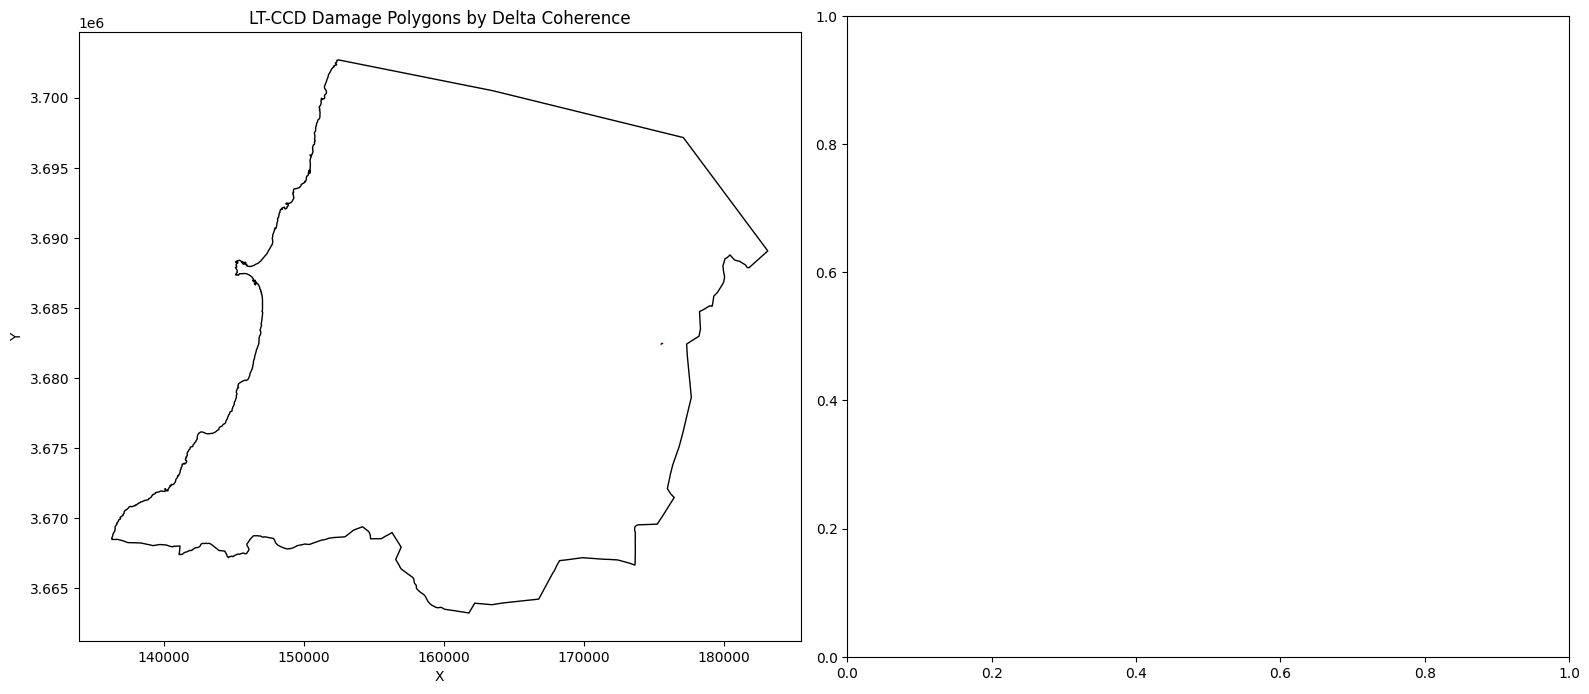

In [116]:
if len(damage_gdf) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    damage_gdf.plot(color="red", edgecolor="black", linewidth=0.3, ax=axes[0])
    aoi_gdf.to_crs(damage_gdf.crs).boundary.plot(ax=axes[0], color="black", linewidth=1)
    axes[0].set_title("LT-CCD Damage Polygons by Delta Coherence")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")

    plt.tight_layout()
    plt.show()
else:
    print("No damage polygons available for plotting")

In [117]:
if use_buildings:
    print("🏠 Aggregating damage to building footprints...")

    buildings_gdf = gpd.read_file(buildings_path)
    if buildings_gdf.empty:
        raise ValueError(f"Buildings file is empty: {buildings_path}")

    buildings_gdf = buildings_gdf.to_crs(ref_meta["crs"]).copy()
    buildings_gdf["building_id"] = np.arange(len(buildings_gdf))
    buildings_gdf["building_area_m2"] = buildings_gdf.geometry.area

    if len(damage_gdf) == 0:
        buildings_gdf["damage_area_m2"] = 0.0
        buildings_gdf["damage_fraction"] = 0.0
        buildings_gdf["is_damaged"] = 0
        damaged_buildings = buildings_gdf.iloc[0:0].copy()
    else:
        
        intersections = gpd.overlay(
            buildings_gdf[["building_id", "building_area_m2", "geometry"]],
            damage_gdf[["geometry"]],
            how="intersection"
        )

        if len(intersections) > 0:
            intersections["intersect_area_m2"] = intersections.geometry.area

            damage_by_building = (
                intersections.groupby("building_id", as_index=False)["intersect_area_m2"]
                .sum()
                .rename(columns={"intersect_area_m2": "damage_area_m2"})
            )

            buildings_gdf = buildings_gdf.merge(damage_by_building, on="building_id", how="left")
            buildings_gdf["damage_area_m2"] = buildings_gdf["damage_area_m2"].fillna(0.0)
            buildings_gdf["damage_fraction"] = buildings_gdf["damage_area_m2"] / buildings_gdf["building_area_m2"]
            buildings_gdf["is_damaged"] = (buildings_gdf["damage_fraction"] >= building_damage_fraction_threshold).astype("uint8")
            damaged_buildings = buildings_gdf[buildings_gdf["is_damaged"] == 1].copy()
        else:
            buildings_gdf["damage_area_m2"] = 0.0
            buildings_gdf["damage_fraction"] = 0.0
            buildings_gdf["is_damaged"] = 0
            damaged_buildings = buildings_gdf.iloc[0:0].copy()

    buildings_csv = table_dir / "buildings_damage_table.csv"
    buildings_geojson = vector_dir / "damaged_buildings.geojson"

    pd.DataFrame(buildings_gdf.drop(columns="geometry")).to_csv(buildings_csv, index=False)

    if len(damaged_buildings) > 0:
        damaged_buildings.to_file(buildings_geojson, driver="GeoJSON")

    print(f"   ✅ Total buildings: {len(buildings_gdf):,}")
    print(f"   ✅ Damaged buildings: {len(damaged_buildings):,}")
    print(f"   ✅ Building table saved: {buildings_csv}")
    if len(damaged_buildings) > 0:
        print(f"   ✅ Damaged buildings saved: {buildings_geojson}")
else:
    buildings_gdf = None
    damaged_buildings = None

In [118]:
if use_buildings and damaged_buildings is not None and len(damaged_buildings) > 0:
    fig, ax = plt.subplots(figsize=(10, 10))
    aoi_gdf.to_crs(ref_meta["crs"]).boundary.plot(ax=ax, color="black", linewidth=1)
    damaged_buildings.plot(ax=ax, color="red", alpha=0.7, edgecolor="none")
    ax.set_title("Damaged Buildings (LT-CCD)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.tight_layout()
    plt.show()
elif use_buildings:
    print("No damaged buildings available for plotting")

In [119]:
print("📝 Writing processing summary...")

summary = {
    "processing_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "method": "LT-CCD",
    "inputs": {
        "prepared_post_dir": str(prepared_post_dir),
        "prepared_baseline_dir": str(prepared_baseline_dir),
        "prepared_post_confirm_dir": str(prepared_confirm_dir) if use_temporal_confirmation else None,
        "aoi_path": str(aoi_path),
        "buildings_path": str(buildings_path) if use_buildings else None
    },
    "parameters": {
        "baseline_mean_min": baseline_mean_min,
        "baseline_std_max": baseline_std_max,
        "delta_threshold": delta_threshold,
        "z_threshold": z_threshold,
        "post_mean_min": post_mean_min,
        "min_polygon_area_m2": min_polygon_area_m2,
        "building_damage_fraction_threshold": building_damage_fraction_threshold,
        "use_temporal_confirmation": use_temporal_confirmation,
        "use_buildings": use_buildings,
        "use_slope_mask": use_slope_mask,
        "slope_threshold_deg": slope_threshold_deg,
        "dem_path": str(dem_path) if use_slope_mask else None
    },
    "stack_info": {
        "n_baseline_rasters": len(baseline_files),
        "n_post_rasters": len(post_files),
        "n_confirm_rasters": len(confirm_files) if use_temporal_confirmation else 0,
        "grid_crs": str(ref_meta["crs"]),
        "grid_height": int(ref_meta["height"]),
        "grid_width": int(ref_meta["width"])
    },
    "results": {
        "valid_pixels": valid_pixels,
        "total_pixels": total_pixels,
        "valid_area_km2": valid_area_km2,
        "initial_damage_pixels": initial_damage_pixels,
        "final_damage_pixels": final_damage_pixels,
        "damage_area_km2": damage_area_km2,
        "damage_polygons": int(len(damage_gdf)),
        "valid_dem_pixels": int(valid_dem_pixels) if valid_dem_pixels is not None else None,
        "flat_pixels": int(flat_pixels) if flat_pixels is not None else None,
        "steep_pixels": int(steep_pixels) if steep_pixels is not None else None
    }
}

if use_buildings and buildings_gdf is not None:
    summary["results"]["total_buildings"] = int(len(buildings_gdf))
    summary["results"]["damaged_buildings"] = int(len(damaged_buildings)) if damaged_buildings is not None else 0

summary_path = table_dir / "ltccd_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"   ✅ Summary saved: {summary_path}")

📝 Writing processing summary...
   ✅ Summary saved: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026/tables/ltccd_summary.json


In [120]:
print("🎉 LT-CCD pipeline completed successfully!")

print("\n📋 Final Summary:")
print(f"   Baseline rasters: {len(baseline_files)}")
print(f"   Post rasters: {len(post_files)}")
if use_temporal_confirmation:
    print(f"   Confirmation rasters: {len(confirm_files)}")

print(f"   Valid area: {valid_area_km2:.3f} km²")
print(f"   Final damage area: {damage_area_km2:.3f} km²")
print(f"   Damage polygons: {len(damage_gdf)}")

if use_buildings and damaged_buildings is not None:
    print(f"   Damaged buildings: {len(damaged_buildings):,}")

print("\n📁 Output folders:")
print(f"   Rasters: {raster_dir}")
print(f"   Vectors: {vector_dir}")
print(f"   Tables: {table_dir}")

🎉 LT-CCD pipeline completed successfully!

📋 Final Summary:
   Baseline rasters: 23
   Post rasters: 24
   Confirmation rasters: 24
   Valid area: 61.379 km²
   Final damage area: 0.019 km²
   Damage polygons: 1

📁 Output folders:
   Rasters: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026/rasters
   Vectors: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026/vectors
   Tables: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026/tables
